<a href="https://colab.research.google.com/github/Saransh-Basu-01/50-Ml-Projects-to-understand-LLMs/blob/main/Project_2_Book_Length_in_characters%2Cwords_and_Tokens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
import requests
url1 = 'https://www.'
url2 = 'gutenberg.org/cache/epub/84/pg84.txt'
text = requests.get(url1+url2).text
print(text)

In [2]:

import numpy as np
import requests
import matplotlib.pyplot as plt

# Part 1:Total Characterrs,words and tokens

## Task 1
- The online code file has a list of 10 books and their gutenberg.org
codes. In a for-loop, import each book using the requests library,
count the number of characters, words, and GPT-2 tokens, and report
the results in a table.

In [3]:
from transformers import AutoTokenizer
tokenizer=AutoTokenizer.from_pretrained('gpt2')

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [4]:
baseurl = 'https://www.gutenberg.org/cache/epub/'

bookurls = [
    # code       title
    ['84',    'Frankenstein'    ],
    ['64317', 'GreatGatsby'     ],
    ['11',    'AliceWonderland' ],
    ['1513',  'RomeoJuliet'     ],
    ['76',    'HuckFinn'        ],
    ['219',   'HeartDarkness'   ],
    ['2591',  'GrimmsTales'     ],
    ['2148',  'EdgarAllenPoe'   ],
    ['36',    'WarOfTheWorlds'  ],
    ['829',   'GulliversTravels']
]

In [10]:
for i in bookurls:
  print(i)

['84', 'Frankenstein']
['64317', 'GreatGatsby']
['11', 'AliceWonderland']
['1513', 'RomeoJuliet']
['76', 'HuckFinn']
['219', 'HeartDarkness']
['2591', 'GrimmsTales']
['2148', 'EdgarAllenPoe']
['36', 'WarOfTheWorlds']
['829', 'GulliversTravels']


In [11]:
for code,title in bookurls:
  print(code,title)

84 Frankenstein
64317 GreatGatsby
11 AliceWonderland
1513 RomeoJuliet
76 HuckFinn
219 HeartDarkness
2591 GrimmsTales
2148 EdgarAllenPoe
36 WarOfTheWorlds
829 GulliversTravels


In [5]:
print('  Book title     |  Chars  |  Words  |  Tokens')
print('-----------------+---------+---------+---------')

for code,title in bookurls:

  # get the text
  fullurl = baseurl + code + '/pg' + code + '.txt'
  text = requests.get(fullurl).text

  # counts of different token types
  n_chars = len(text)
  n_words = len(text.split())
  n_token = len(tokenizer.encode(text))

  # print the results
  print(f'{title:16} | {n_chars:>7,d} | {n_words:>7,d} | {n_token:>7,d}')

  Book title     |  Chars  |  Words  |  Tokens
-----------------+---------+---------+---------


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (114213 > 1024). Running this sequence through the model will result in indexing errors


Frankenstein     | 446,582 |  78,106 | 114,213
GreatGatsby      | 296,899 |  51,262 |  89,263
AliceWonderland  | 167,712 |  29,569 |  52,948
RomeoJuliet      | 167,469 |  29,005 |  56,180
HuckFinn         | 602,752 | 114,130 | 193,373
HeartDarkness    | 232,924 |  40,957 |  63,988
GrimmsTales      | 549,776 | 104,156 | 158,433
EdgarAllenPoe    | 632,171 |  98,105 | 197,302
WarOfTheWorlds   | 363,440 |  63,118 |  96,422
GulliversTravels | 611,781 | 108,140 | 158,340


# Part 2:Unique and Total counts

## Task 1:
- Write code to create Figure 2.6. The figure shows the total (left) and
unique (right) number of characters, words, and tokens. Each marker
represents a book, and the horizontal bar is the average over all the
books.

In [8]:
totals

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [15]:
totals[1,1]

np.int64(0)

In [18]:
totals = np.zeros((3,len(bookurls)),dtype=int)
uniques = np.zeros((3,len(bookurls)),dtype=int)
for i,(code,title) in enumerate(bookurls):
  fullurl = baseurl + code + '/pg' + code + '.txt'
  text = requests.get(fullurl).text
  #character
  totals[0,i]=len(text)
  uniques[0,i]=len(set(text))
  #words
  totals[1,i]=len(text.split())
  uniques[1,i]=len(set(text.split()))
  #tokens
  tokens=tokenizer.encode(text)
  totals[2,i]=len(tokens)
  uniques[2,i]=len(set(tokens))

In [19]:
totals

array([[446582, 296899, 167712, 167469, 602752, 232924, 549776, 632171,
        363440, 611781],
       [ 78106,  51262,  29569,  29005, 114130,  40957, 104156,  98105,
         63118, 108140],
       [114213,  89263,  52948,  56180, 193373,  63988, 158433, 197302,
         96422, 158340]])

In [20]:
uniques

array([[   94,    95,    92,    92,    89,    91,    92,   111,    92,
           94],
       [12179, 10210,  5973,  6957, 14308,  9555, 10918, 18445, 11417,
        14491],
       [ 9239,  8151,  4510,  5196,  8353,  7486,  7152, 11225,  9131,
        10274]])

In [21]:
totals[1,1]

np.int64(51262)

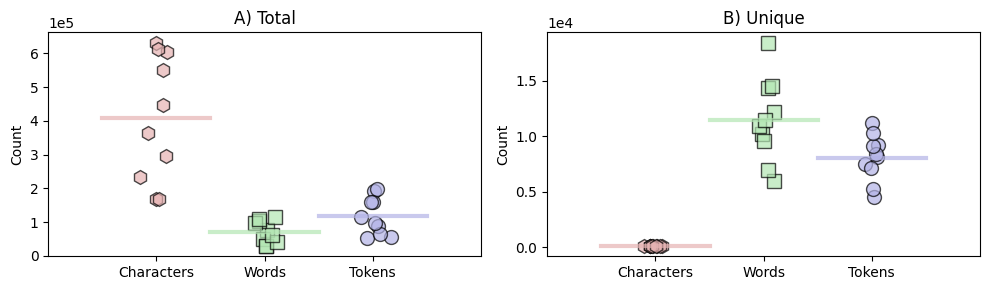

In [22]:
_,axs = plt.subplots(1,2,figsize=(10,3))

# marker colors and shapes
colors = [ [.9,.7,.7,.7],[.7,.9,.7,.7],[.7,.7,.9,.7] ]
shapes = 'hso'

# loop over the three tokenizer features
for i in range(3):

  # draw the individual data points
  axs[0].plot(np.random.normal(i,.06,len(bookurls)),totals[i,:],'k'+shapes[i],
              markerfacecolor=colors[i],markersize=10)

  # and the mean
  axs[0].plot([i-.5,i+.5],np.mean(totals[i,:])*np.ones(2),
              color=colors[i],linewidth=3)


  # repeat for unique counts
  axs[1].plot(np.random.normal(i,.06,len(bookurls)),uniques[i,:],'k'+shapes[i],
              markerfacecolor=colors[i],markersize=10)
  axs[1].plot([i-.5,i+.5],np.mean(uniques[i,:])*np.ones(2),
              color=colors[i],linewidth=3)

# axis adjustments
axs[0].set(xticks=[0,1,2],xticklabels=['Characters','Words','Tokens'],
           xlim=[-1,3],ylabel='Count',title='A) Total')
axs[1].set(xticks=[0,1,2],xticklabels=['Characters','Words','Tokens'],
           xlim=[-1,3],ylabel='Count',title='B) Unique')


axs[0].ticklabel_format(style='scientific',axis='y',scilimits=(0,0))
axs[1].ticklabel_format(style='scientific',axis='y',scilimits=(0,0))

plt.tight_layout()
plt.show()

# Part 3:Unique by Total counts

## Task 1:
- Write code to produce Figure 2.7. You can calculate the correlation
coefficient using np.corrcoef.

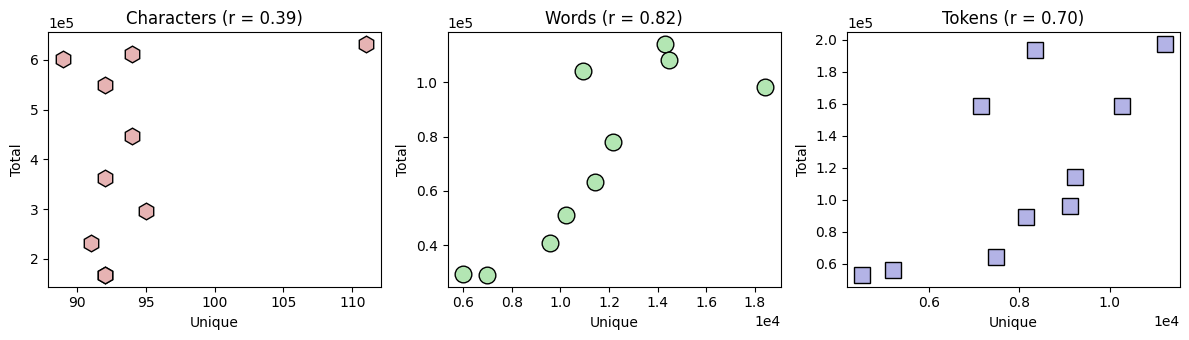

In [41]:
_,axs = plt.subplots(1,3,figsize=(12,3.5))

markers = [ 'kh','ko','ks' ]
labels = [ 'Characters','Words','Tokens' ]

for i in range(3):

  # pick the color for these markers
  color = [.7,.7,.7]
  color[i] = .9

  # correlation between total and unique count
  r = np.corrcoef(uniques[i,:],totals[i,:])[0,1]
  title = f'{labels[i]} (r = {r:.2f})'

  # make the plot
  axs[i].plot(uniques[i,:],totals[i,:],markers[i],markerfacecolor=color,markersize=12)
  axs[i].set(xlabel='Unique',ylabel='Total',title=title)

  # scientific notation in plot labels (except for characters)
  if i==0:
    axs[i].ticklabel_format(style='scientific',axis='y',scilimits=(0,0))
  else:
    axs[i].ticklabel_format(style='scientific',axis='both',scilimits=(0,0))


plt.tight_layout()
plt.show()

## task 2
- Find which book is the outlier and print out the set of unique char
acters for inspection.

In [59]:
bookurls[uniques[0,:].argmax()][1]

'EdgarAllenPoe'

In [49]:
uniques

array([[   94,    95,    92,    92,    89,    91,    92,   111,    92,
           94],
       [12179, 10210,  5973,  6957, 14308,  9555, 10918, 18445, 11417,
        14491],
       [ 9239,  8151,  4510,  5196,  8353,  7486,  7152, 11225,  9131,
        10274]])

In [54]:
uniques[0,:]

array([ 94,  95,  92,  92,  89,  91,  92, 111,  92,  94])

In [53]:
uniques[0,:].argmax()

np.int64(7)

In [58]:
bookurls[uniques[0,:].argmax()][1]

'EdgarAllenPoe'

In [60]:
bookurls[uniques[1,:].argmax()][1]

'EdgarAllenPoe'

In [61]:
bookurls[uniques[2,:].argmax()][1]


'EdgarAllenPoe'